# AudioDNA — Exploratory Data Analysis

Dataset: ~900 game sound effects from [Freesound.org](https://freesound.org),
150 per category, collected in Phase 2; 37-dimensional feature vectors
extracted in Phase 3.

Questions this notebook answers:

1. Is the dataset balanced, and how do clip durations differ by category?
2. What do the categories *look* like as waveforms and mel spectrograms?
3. Which individual features separate the categories?
4. Do the categories form visible clusters in a 2D PCA projection —
   i.e., is classification plausible at all?

In [1]:
import json
import sys
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make `src` importable whether this runs from notebooks/ or the project root.
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.config import CATEGORIES, SAMPLE_RATE
from src.db import get_connection

sns.set_theme(style="whitegrid")
PALETTE = dict(zip(CATEGORIES, sns.color_palette("deep", len(CATEGORIES))))

# Join metadata with features. The JSON feature dicts expand into one
# DataFrame column per feature via json_normalize.
# (s.duration is aliased: the API-reported duration differs slightly from
# the post-silence-trim `duration` computed in Phase 3.)
with get_connection() as conn:
    meta = pd.read_sql(
        """SELECT s.id, s.name, s.category, s.duration AS api_duration,
                  s.filepath, f.feature_json
           FROM sounds s JOIN features f ON f.sound_id = s.id""",
        conn,
    )

feat = pd.json_normalize(meta.pop("feature_json").map(json.loads))
FEATURE_COLS = list(feat.columns)
df = pd.concat([meta, feat], axis=1)
print(f"{len(df)} sounds, {len(FEATURE_COLS)} features each")
df.head(3)

899 sounds, 37 features each


,id,name,category,api_duration,filepath,mfcc1_mean,mfcc1_std,mfcc2_mean,mfcc2_std,mfcc3_mean,...,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,zero_crossing_rate_mean,zero_crossing_rate_std,rms_mean,rms_std,duration
0,1,Hit Impact,impact,0.444898,data\raw\impact\660770.mp3,-242.942032,140.141541,-0.031389,9.588408,27.560949,...,961.786860,3362.803740,248.957843,8225.683594,385.170289,0.129661,0.069351,0.106430,0.093062,0.232200
1,2,"Car Impact Hit, Shatter, No Glass",impact,1.189640,data\raw\impact\681527.mp3,-93.386917,140.962784,101.589134,22.746878,-11.366253,...,574.947993,2295.523761,207.336628,4535.005911,986.704716,0.110788,0.054219,0.141588,0.097866,0.417959
2,3,"Swish hit. Metal impact(11lrs,mltprcssng).wav",impact,6.573750,data\raw\impact\554145.mp3,-359.178772,134.543427,98.845123,44.568783,48.468143,...,1035.676933,951.126120,817.985014,1127.339311,2313.591741,0.038056,0.085094,0.107579,0.117902,2.275556


## 1. Class balance and durations

A balanced dataset means accuracy is a meaningful metric later (with
imbalanced classes, a model can score high by always predicting the
majority class). Duration is plotted on a log scale because it spans
two orders of magnitude (~0.1 s blips to 10 s ambiences).

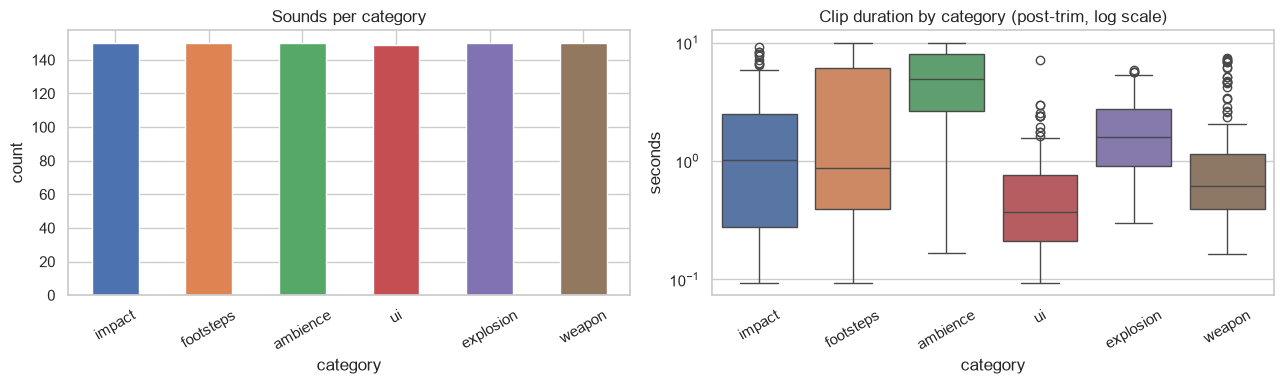

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
ambience,150.0,5.10,2.98,0.17,2.65,4.92,7.95,10.00
explosion,150.0,1.92,1.28,0.30,0.91,1.58,2.75,5.83
footsteps,150.0,2.88,3.18,0.09,0.39,0.88,6.09,10.00
impact,150.0,1.82,2.03,0.09,0.28,1.01,2.51,9.10
ui,149.0,0.65,0.81,0.09,0.21,0.37,0.77,7.13
weapon,150.0,1.26,1.68,0.16,0.39,0.62,1.14,7.38


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df["category"].value_counts().reindex(CATEGORIES)
counts.plot.bar(ax=axes[0], color=[PALETTE[c] for c in CATEGORIES])
axes[0].set_title("Sounds per category")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="category", y="duration", order=CATEGORIES,
            hue="category", palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Clip duration by category (post-trim, log scale)")
axes[1].set_ylabel("seconds")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

df.groupby("category")["duration"].describe().round(2)

## 2. What does each category look like?

For each category we plot one representative clip (the one closest to the
category's median duration) two ways:

- **Waveform** — raw amplitude over time. Shows the *energy envelope*:
  impacts are a single sharp spike with fast decay, ambiences are a
  near-constant band.
- **Mel spectrogram** — energy per frequency band over time, with the
  frequency axis warped to the *mel scale* (which spaces frequencies the
  way human pitch perception does — more resolution at low frequencies)
  and color in decibels. This is the picture our MFCC features summarize:
  MFCCs are essentially a compact encoding of each spectrogram column.

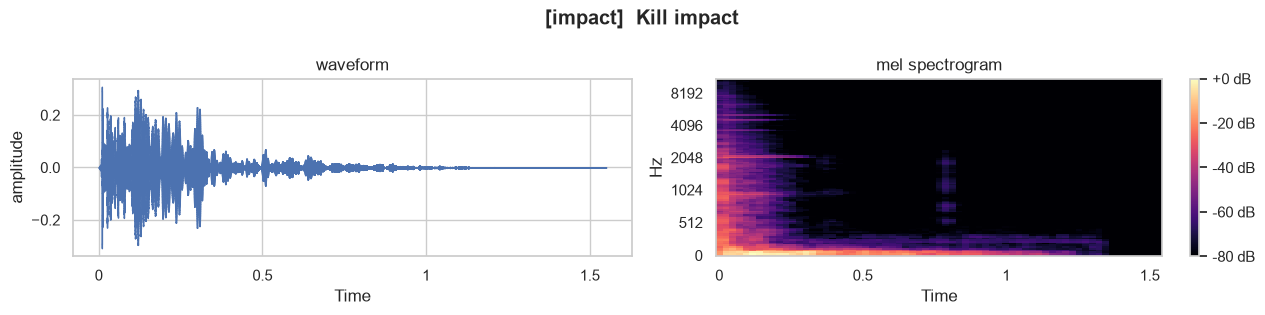

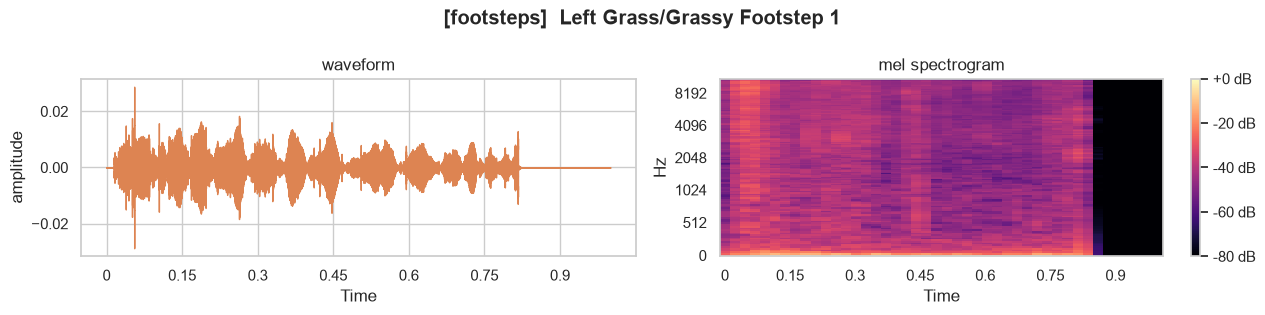

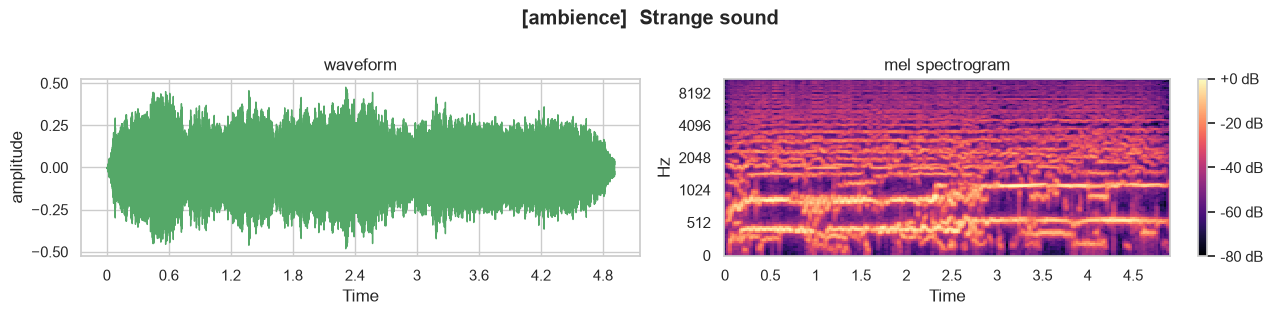

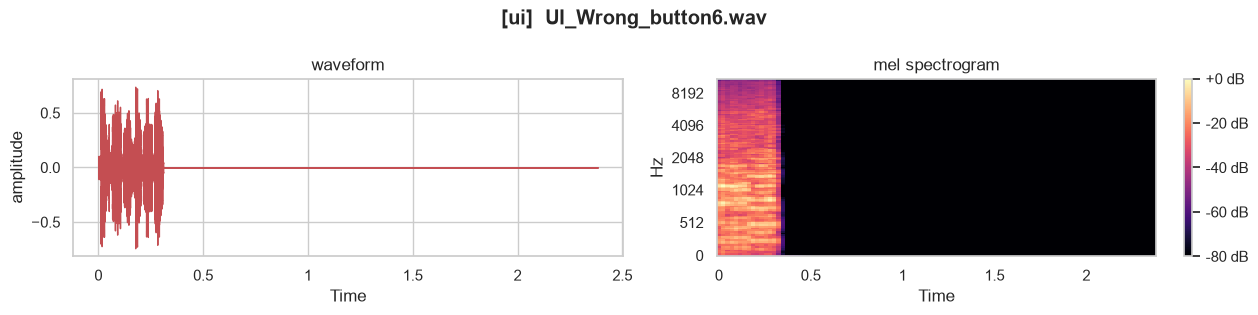

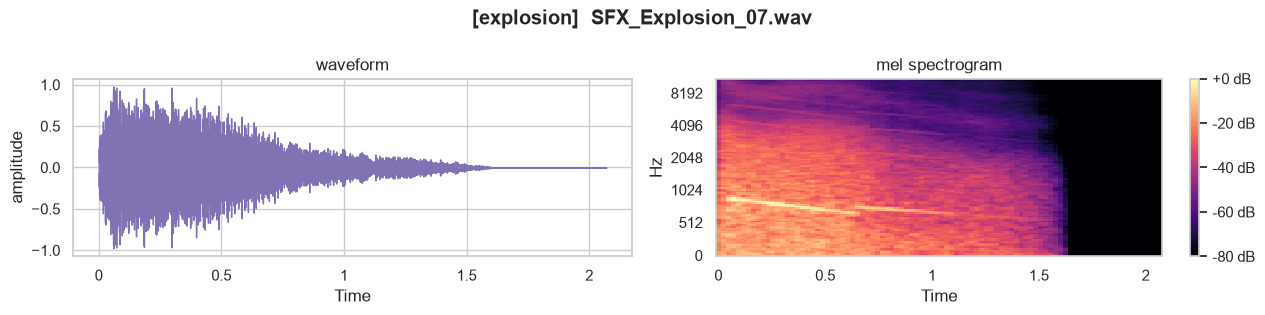

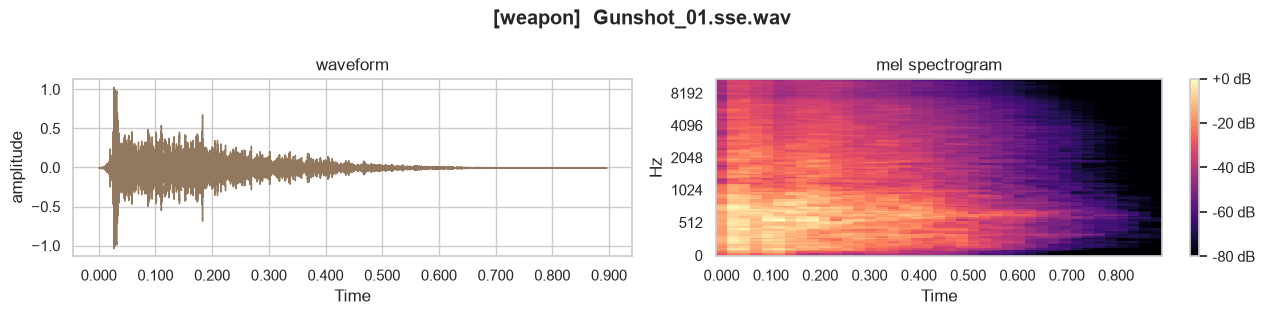

In [3]:
def example_sound(cat):
    """The sound whose duration is closest to the category median —
    a 'typical' clip, more representative than a random draw."""
    sub = df[df["category"] == cat]
    idx = (sub["duration"] - sub["duration"].median()).abs().idxmin()
    return df.loc[idx]

for cat in CATEGORIES:
    row = example_sound(cat)
    y, sr = librosa.load(ROOT / row["filepath"], sr=SAMPLE_RATE, mono=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
    librosa.display.waveshow(y, sr=sr, ax=axes[0], color=PALETTE[cat])
    axes[0].set_title("waveform")
    axes[0].set_ylabel("amplitude")

    # power_to_db converts raw power to decibels (log scale), matching how
    # loudness is perceived; ref=np.max puts 0 dB at the loudest point.
    S = librosa.feature.melspectrogram(y=y, sr=sr)
    img = librosa.display.specshow(librosa.power_to_db(S, ref=np.max),
                                   sr=sr, x_axis="time", y_axis="mel",
                                   ax=axes[1], cmap="magma")
    axes[1].set_title("mel spectrogram")
    fig.colorbar(img, ax=axes[1], format="%+2.0f dB")

    fig.suptitle(f"[{cat}]  {row['name'][:70]}", fontweight="bold")
    plt.tight_layout()
    plt.show()

## 3. Which features separate the categories?

Boxplots of four hand-picked features. If the boxes for different
categories barely overlap, that feature alone carries class information —
a good omen for the classifier.

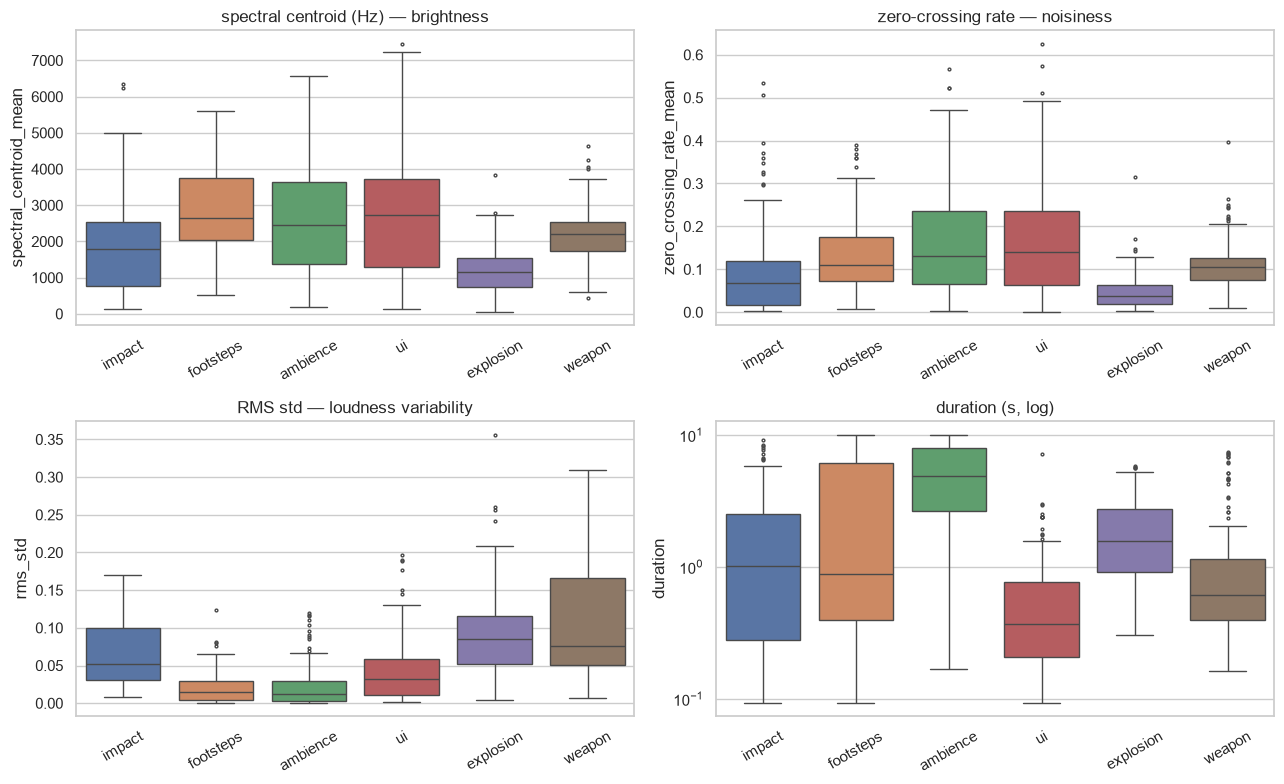

,spectral_centroid_mean,zero_crossing_rate_mean,rms_std,duration
category,,,,
ambience,2572.758,0.168,0.022,5.100
explosion,1208.618,0.046,0.089,1.919
footsteps,2865.712,0.131,0.019,2.884
impact,1873.354,0.092,0.065,1.818
ui,2667.886,0.168,0.044,0.654
weapon,2176.807,0.109,0.110,1.257


In [4]:
PLOT_FEATURES = {
    "spectral_centroid_mean": "spectral centroid (Hz) — brightness",
    "zero_crossing_rate_mean": "zero-crossing rate — noisiness",
    "rms_std": "RMS std — loudness variability",
    "duration": "duration (s, log)",
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (col, label) in zip(axes.flat, PLOT_FEATURES.items()):
    sns.boxplot(data=df, x="category", y=col, order=CATEGORIES,
                hue="category", palette=PALETTE, legend=False,
                ax=ax, fliersize=2)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    if col == "duration":
        ax.set_yscale("log")
plt.tight_layout()
plt.show()

df.groupby("category")[list(PLOT_FEATURES)].mean().round(3)

## 4. PCA — do categories cluster?

PCA (Principal Component Analysis) rotates the 37-dimensional feature
space so the first two axes capture as much variance as possible, letting
us *see* the data in 2D. Features are standardized first (zero mean, unit
variance) because PCA chases variance: without scaling, MFCC-1 (range
~hundreds) would drown out zero-crossing rate (range ~0–0.5).

Caveat: 2D shows only part of the variance. Categories that overlap here
may still be separable in the full 37-D space — but clusters that are
visible even in 2D are a strong signal that classification will work.

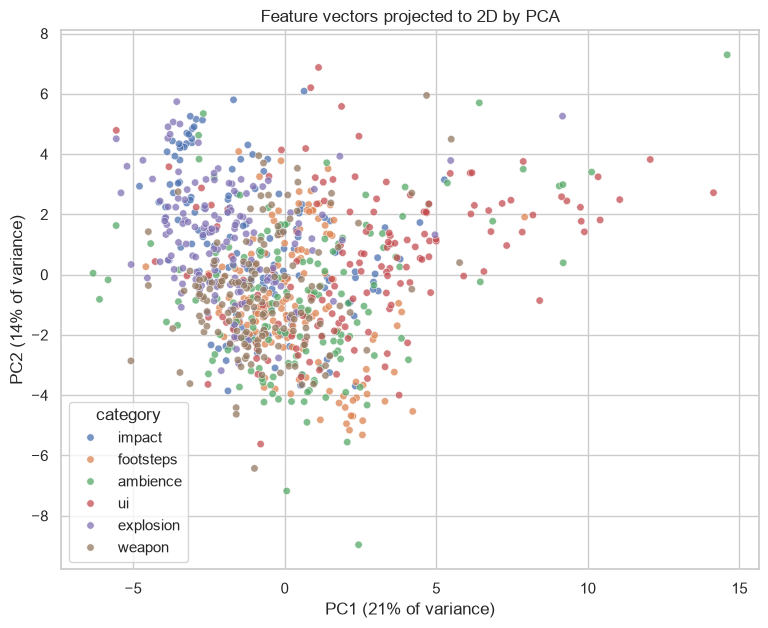

PC1+PC2 explain 36% of total variance


,PC1,PC2
category,,
ambience,0.62,-0.78
explosion,-1.95,1.13
footsteps,0.30,-0.99
impact,-0.92,0.84
ui,2.69,0.50
weapon,-0.73,-0.70


In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(df[FEATURE_COLS])
pca = PCA(n_components=2, random_state=42)
XY = pca.fit_transform(X)

evr = pca.explained_variance_ratio_
plt.figure(figsize=(9, 7))
sns.scatterplot(x=XY[:, 0], y=XY[:, 1], hue=df["category"],
                hue_order=CATEGORIES, palette=PALETTE, s=28, alpha=0.75)
plt.xlabel(f"PC1 ({evr[0]:.0%} of variance)")
plt.ylabel(f"PC2 ({evr[1]:.0%} of variance)")
plt.title("Feature vectors projected to 2D by PCA")
plt.legend(title="category")
plt.show()

print(f"PC1+PC2 explain {evr.sum():.0%} of total variance")
centroids = (pd.DataFrame(XY, columns=["PC1", "PC2"])
             .assign(category=df["category"].values)
             .groupby("category").mean().round(2))
centroids

## Interpretation

**The dataset is balanced and classification looks plausible.** All six
categories have 149–150 sounds (one near-silent ambience clip was dropped
during feature extraction).

**Duration is a strong but slightly dangerous feature.** `ui` sounds are
short blips (median 0.4 s) and `ambience` clips long (median ~5 s) — that
alone separates those two classes well. The risk: our 10-second collection
cap means duration partly reflects *how we collected* the data, not the
sounds themselves. `footsteps` is notably bimodal (25th percentile 0.4 s,
75th percentile 6.1 s): uploaders post both single steps and walking loops.

**Individual features behave the way acoustics predicts.**
`explosion` has by far the lowest spectral centroid (~1200 Hz vs.
~2600–2900 Hz for `ui`/`footsteps`/`ambience`) and the lowest
zero-crossing rate — explosions are rumbles, dominated by low frequencies.
`weapon` and `explosion` have the highest RMS std — sudden loud bursts
against silence — while `ambience` and `footsteps` have the lowest, being
relatively steady over time.

**The PCA scatter (36% of variance in 2D) shows the expected structure:**

- `ui` sits far to the right on PC1 (centroid +2.7), clearly separated —
  short, bright, tonal blips really are acoustically distinctive.
- `explosion`, `impact`, and `weapon` cluster together on the left
  (PC1 ≈ −0.7 to −2.0): all are percussive low-frequency bursts. **This is
  where the classifier will struggle** — expect the confusion matrix in
  Phase 5 to mix these three.
- `ambience` and `footsteps` overlap in the lower-middle region; both are
  sustained, broadband, relatively steady sounds (many footstep clips are
  long walking loops, which makes them ambience-like).

Only 36% of variance fits in 2D, so the full 37-D space likely separates
the classes better than this picture suggests — a model has room to beat
what the eye can see here.